# Introduction

## Project Overview: Predicting Risk in Shelter Animals

**Background:** This project addresses a critical challenge in animal shelter management: identifying animals at high risk of negative outcomes upon intake. Using the *Louisville Metro KY - Animal Service Intake and Outcome* dataset, we aim to build a predictive model that classifies whether an animal is "At-Risk."

> **Definition of "At-Risk":** In this study, an animal is defined as "At-Risk" if its final outcome is categorized as *Euthanasia, Died, or Disposal*.

### 🎯 Objectives
* **Perform a comprehensive Exploratory Data Analysis (EDA)** to identify key risk factors (e.g., breed, intake type, biting history).
* **Implement and compare various machine learning models** (Logistic Regression, Random Forest, XGBoost) to predict the outcome.
* **Use clustering techniques** to identify common "risk profiles" of animals entering the shelter.

### 💡 Impact
Early prediction of risk allows shelter staff to prioritize resources, implement targeted behavioral or medical interventions, and ultimately **increase the number of successful adoptions and rescues.**

In [ ]:
!pip install folium
!pip install catboost -q
!pip install kmodes -q
!pip install lightgbm shap prince
!pip install imbalanced-learn
!pip install --upgrade seaborn

!pip uninstall numpy -y
!pip install "numpy<2.0"

!pip uninstall scipy scikit-learn -y
!pip install scipy scikit-learn

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import seaborn as sns
import re
import lightgbm as lgb
import shap
import prince
import plotly.express as px

from scipy.stats import randint, loguniform, uniform
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, recall_score, make_scorer
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.inspection import permutation_importance
from sklearn.metrics import average_precision_score, precision_recall_fscore_support
from kmodes.kmodes import KModes
from catboost import CatBoostClassifier
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import pdist, squareform

In [4]:
data_frame = pd.read_excel('Animal_IO_Data.csv')

In [5]:
df = data_frame.copy()

---

# Cleaning The Data #

Data Preprocessing and Feature Engineering

In this stage, we prepare the raw data for analysis and modeling. The raw dataset contains several categorical variables and timestamps that require transformation.

In [6]:
df.outtype.unique()

<StringArray>
[     'EUTH',    'FOSTER',  'ADOPTION',  'DISPOSAL',       'RTO',      'DIED',
       'SNR',       'TNR',       'RTF', 'TRANSPORT',         nan,  'TRANSFER',
   'RELEASE',      'LOST', 'FOUND EXP']
Length: 15, dtype: str

In [7]:
df = df[df.outtype.notnull()]

In [8]:
df['indate'] = pd.to_datetime(df['indate']).dt.normalize()
df['outdate'] = pd.to_datetime(df['outdate']).dt.normalize()
df.sort_values(by='indate', inplace=True)

Identifying Returning Animals > We create a first_time binary flag to distinguish between new arrivals and animals that have been in the shelter before. This is derived by checking for duplicated Animal IDs.

In [9]:
df['first_time'] = (~df.duplicated('animalid')).astype(int)
df.sort_values(by='ObjectId', inplace=True)

In [10]:
df = df[~df['kennel'].isin(['NECROPSY', 'FREEZER', 'TNR/SNR'])]
df = df[df['surreason'] != 'DOA']
df = df[~df['surreason'].str.contains('AUTH', case=False, na=False)]
df = df[df['intype'] != 'DISPOSAL']
df = df[df['insubtype'] != 'EUTH REQ']

Standardizing Categorical Categories > To reduce noise and improve model stability, we simplify categorical variables:

Animal Type: Rare species are grouped into an "OTHER" category.

Pet Size: Young animals ("PUPPY", "KITTN") are merged into a single "PUPPY/KITTN" group, reflecting their similar risk profiles.

In [11]:
df['animaltype'] = df['animaltype'].replace('LIVESTOCK', 'OTHER')
df['petsize'] = df['petsize'].replace(['PUPPY', 'KITTN'], 'PUPPY/KITTN')

Feature Extraction: Breed Complexity > We extract the mixed_breed feature from the raw text to determine if an animal is a purebred or a mix. Mixed breeds often face different adoption challenges than purebreds.

In [12]:
df['mixed_breed'] = np.where(df['breed'].str.contains('/|mix', case=False), 1, 0)

Defining the Target Variable (Risk) > Our primary goal is to predict high-risk outcomes. We define an animal as "At-Risk" (1) if its outcome is Euthanasia, Death, or Disposal. All other outcomes are classified as "Safe" (0).

In [13]:
at_risk_outtypes = ['DISPOSAL', 'EUTH', 'DIED']
df['will_die'] = np.where(
    (df['outtype'].isin(at_risk_outtypes)) | (df['outsubtype']=='HOSPICE'),
    1, 0
)

Temporal Feature Engineering > Raw dates are converted into datetime objects to extract the Month and Season of intake. This helps the model capture seasonal trends.

In [14]:
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

df['season'] = df['indate'].dt.month.apply(get_season)

In [15]:
df.isnull().sum()
df.info()

<class 'pandas.DataFrame'>
Index: 43505 entries, 1 to 64667
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   kennel         43505 non-null  str           
 1   animalid       43505 non-null  str           
 2   jurisdiction   43505 non-null  str           
 3   intype         43505 non-null  str           
 4   insubtype      43349 non-null  str           
 5   indate         43505 non-null  datetime64[us]
 6   surreason      43505 non-null  str           
 7   outtype        43505 non-null  str           
 8   outsubtype     39244 non-null  str           
 9   outdate        43504 non-null  datetime64[us]
 10  animaltype     43505 non-null  str           
 11  sex            43505 non-null  str           
 12  bites          43502 non-null  str           
 13  petsize        43501 non-null  str           
 14  color          43504 non-null  str           
 15  breed          43504 non-null  str 

Ensuring Data Integrity > To maintain a high-quality dataset for the machine learning models, we remove records with critical missing values in key features.

In [16]:
all_columns = df.columns.tolist()
exclude_columns = ['sourcezipcode', 'insubtype', 'outsubtype']
columns_to_check = [col for col in all_columns if col not in exclude_columns]
df.dropna(subset=columns_to_check, inplace=True)

## Dropping irrelevant columns

Feature Selection & Preventing Data Leakage We remove features that are either non-predictive (IDs) or cause "Data Leakage." Data leakage occurs when the model is trained on information that wouldn't be available at the time of prediction (like the final outtype). We also drop redundant temporal columns after extracting relevant features.

In [17]:
df_clean = df.drop(columns=['animalid', 'ObjectId', 'indate', 'outdate', 'sourcezipcode', 'outtype', 'outsubtype'])
df_clean.columns

Index(['kennel', 'jurisdiction', 'intype', 'insubtype', 'surreason',
       'animaltype', 'sex', 'bites', 'petsize', 'color', 'breed', 'first_time',
       'mixed_breed', 'will_die', 'season'],
      dtype='str')

In [18]:
functional_areas = {'FOSTER', 'INTAKE', 'OFFICE', 'BARN', 'ACO UNIT'}
def get_kennel_group(k):
    k = str(k).strip().upper()
    if k in functional_areas: return k
    match = re.match(r'^([A-Z]+)', k)
    return match.group(1) if match else 'Other'

df_clean['kennel'] = df_clean['kennel'].apply(get_kennel_group)

# Visualizations #

##### Note: In few of the following plots we were using the help of AI

In [19]:
df_vis = df_clean.copy()

  ### Target Variabe Distribution

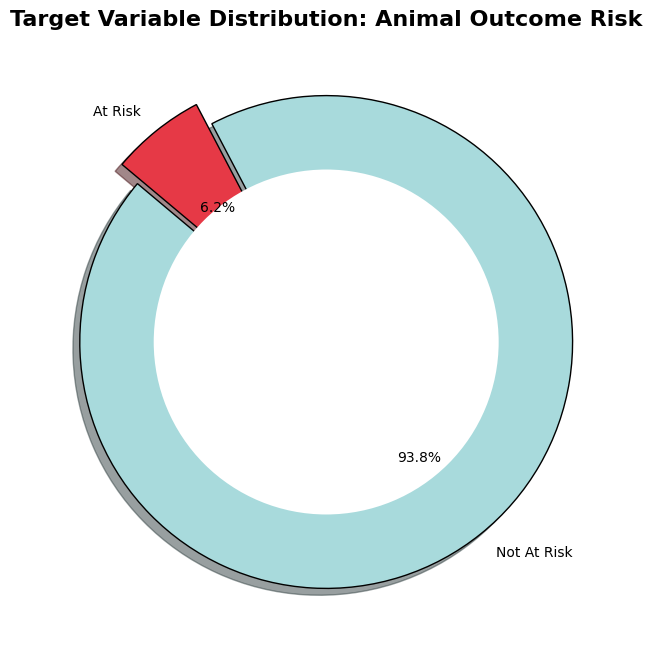

In [20]:
plt.figure(figsize=(8, 8))

counts = df_vis['will_die'].value_counts()
labels = ['Not At Risk', 'At Risk']
colors_me = ['#a8dadc', '#e63946']
explode = (0, 0.1)
plt.pie(counts, labels=labels, autopct='%1.1f%%', startangle=140,
        colors=colors_me, explode=explode, shadow=True, wedgeprops={'edgecolor': 'black'})

centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Target Variable Distribution: Animal Outcome Risk', fontsize=16, fontweight='bold')
plt.show()

This graph shows the distribution of our target variable.

### Risk rate analysis by animal type

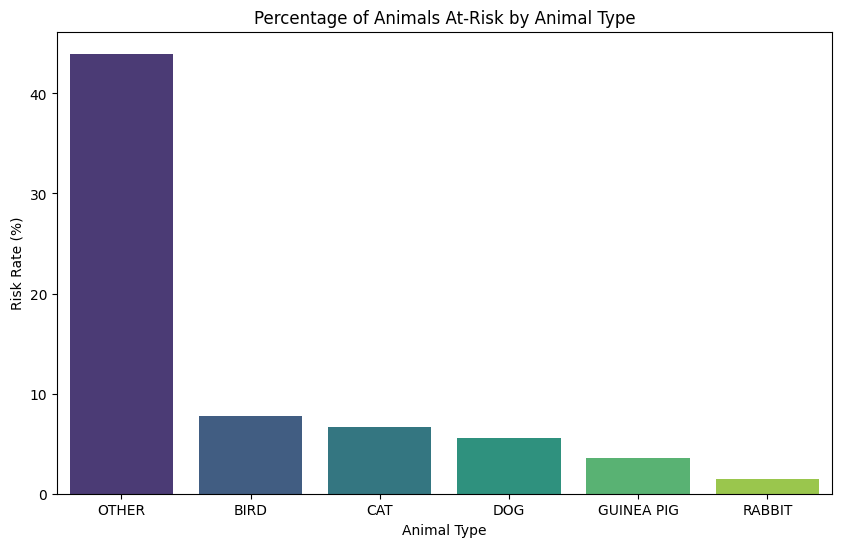

In [21]:
plt.figure(figsize=(10, 6))
risk_rate_animal = df_vis.groupby('animaltype')['will_die'].mean().sort_values(ascending=False) * 100
sns.barplot(x=risk_rate_animal.index, y=risk_rate_animal.values, palette='viridis', hue=risk_rate_animal.index)

plt.title('Percentage of Animals At-Risk by Animal Type')
plt.ylabel('Risk Rate (%)')
plt.xlabel('Animal Type')
plt.show()

This graph shows the percentage of animals that were defined as “at risk” (death, anesthesia, or castration) out of the total animals of each type. Unlike a regular quantitative graph, here you can see which types of animals are statistically more vulnerable. For example, if the percentage of risk among cats is significantly higher than dogs, our future model will give more weight to this variable in the decision-making process.


### The relationship between the method of entry into the shelter (Intype) and risk

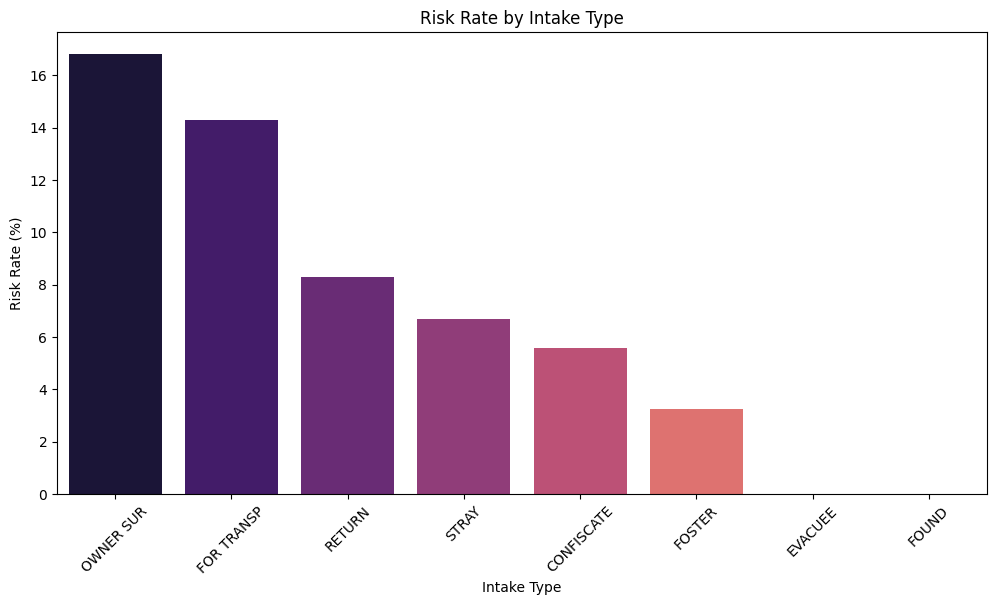

In [22]:
plt.figure(figsize=(12, 6))
risk_rate_intype = df_vis.groupby('intype')['will_die'].mean().sort_values(ascending=False) * 100
sns.barplot(x=risk_rate_intype.index, y=risk_rate_intype.values, palette='magma', hue=risk_rate_intype.index)

plt.title('Risk Rate by Intake Type')
plt.ylabel('Risk Rate (%)')
plt.xlabel('Intake Type')
plt.xticks(rotation=45)
plt.show()

Here we examine whether the circumstances of arrival at the shelter affect the animal's chances of survival. It can be seen that animals that arrive under certain circumstances (e.g., Owner surrendered) are at much higher risk than those found as strays. This information is essential for the shelter to prioritize resources and provide preventative care for animals that arrive from these risk groups.

> Add blockquote



### Impact of Biting History on Animal Risk

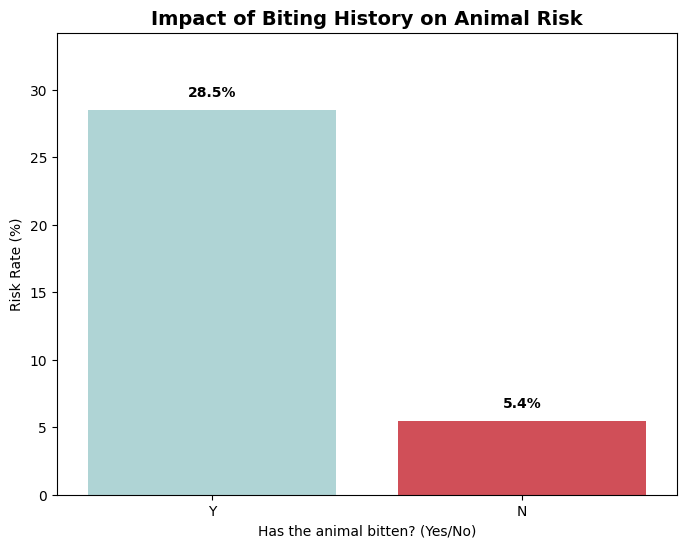

In [23]:
plt.figure(figsize=(8, 6))
risk_bites = df_vis.groupby('bites')['will_die'].mean().sort_index(ascending=False) * 100

sns.barplot(x=risk_bites.index, y=risk_bites.values, palette=colors_me, hue=risk_bites.index)
plt.title('Impact of Biting History on Animal Risk', fontsize=14, fontweight='bold')
plt.ylabel('Risk Rate (%)')
plt.xlabel('Has the animal bitten? (Yes/No)')

for i, v in enumerate(risk_bites.values):
    plt.text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

plt.ylim(0, max(risk_bites.values) * 1.2)
plt.show()

This is one of the strongest predictors in our model. The use of red highlights that an animal with a history of biting is at significantly (many times) higher risk than an animal without such a history. For the shelter, this is an immediate “red flag” that requires urgent behavioral assessment.

### Distribution of Animals At Risk by Intake Month

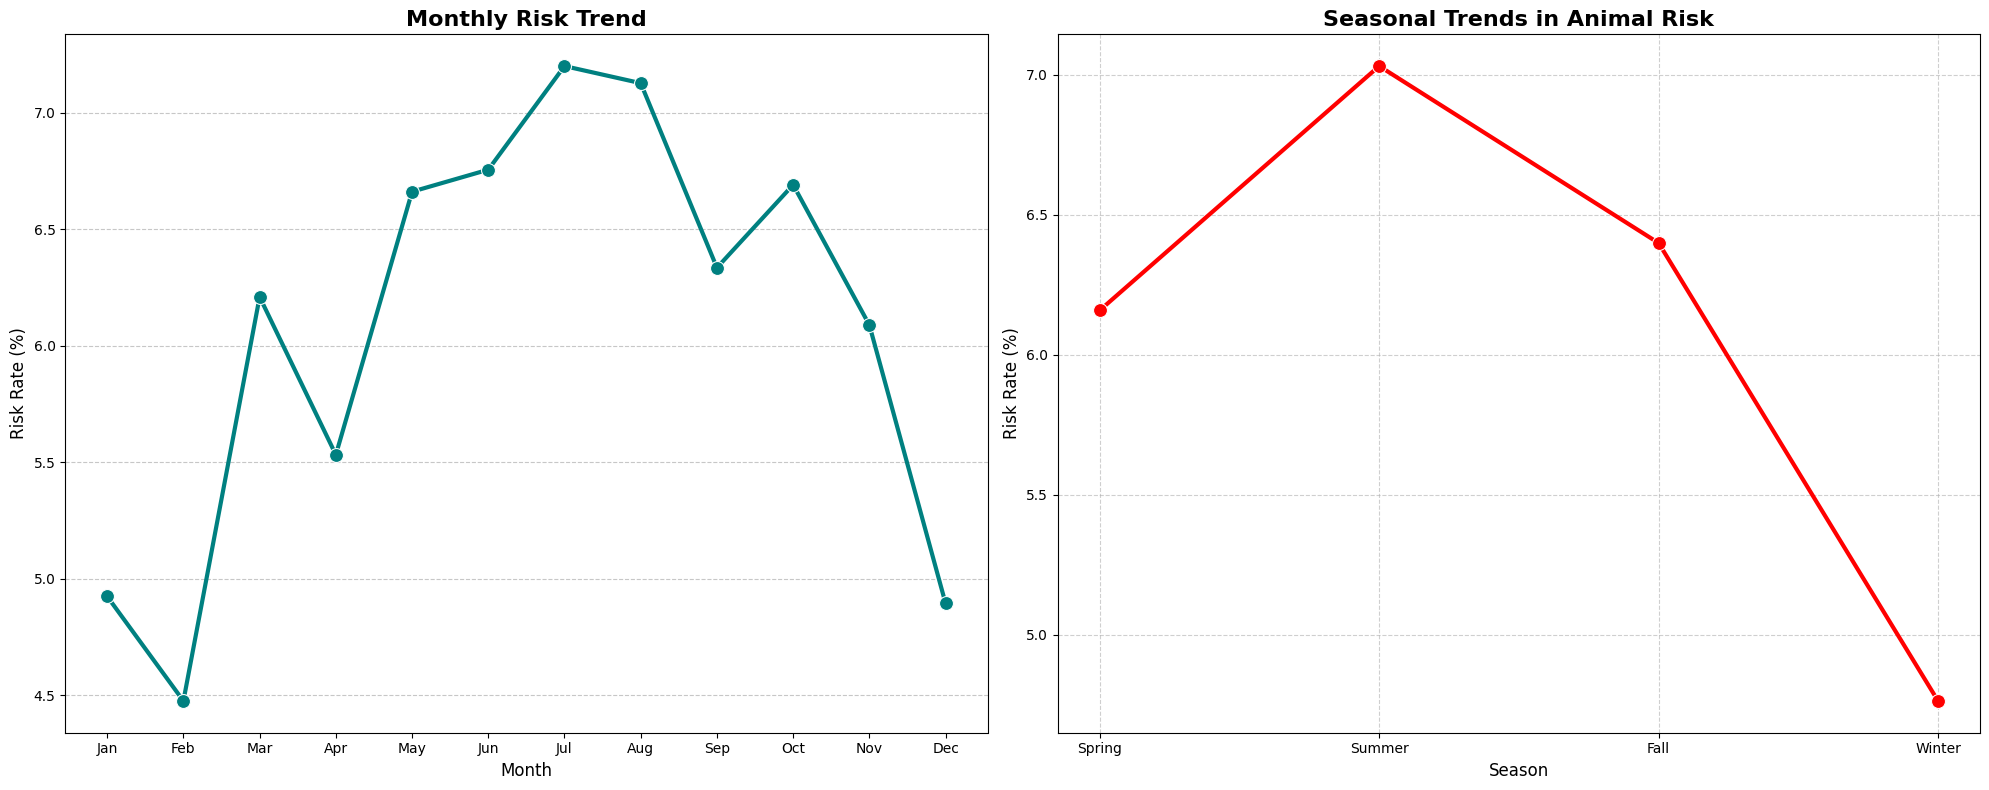

In [24]:
# 1. Prepare Figure and Subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# Monthly Risk Trend

# 2. Calculate Monthly Risk Rate
df_vis['month'] = df['indate'].dt.month
risk_month = df_vis.groupby('month')['will_die'].mean() * 100

# 3. Plot Monthly Trend
sns.lineplot(ax=ax1, x=risk_month.index, y=risk_month.values, marker='o',
             markersize=10, color='teal', linewidth=3)

# 4. Format Monthly Plot
ax1.set_title('Monthly Risk Trend', fontsize=16, fontweight='bold')
ax1.set_ylabel('Risk Rate (%)', fontsize=12)
ax1.set_xlabel('Month', fontsize=12)
ax1.set_xticks(range(1, 13))
ax1.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
ax1.grid(axis='y', linestyle='--', alpha=0.7)


# Seasonal Risk Trend

# 5. Calculate Seasonal Risk Rate
order = ['Spring', 'Summer', 'Fall', 'Winter']
risk_rate_season = df_vis.groupby('season')['will_die'].mean().reindex(order) * 100

# 6. Plot Seasonal Trend
sns.lineplot(ax=ax2, x=risk_rate_season.index, y=risk_rate_season.values,
             marker='o', markersize=10, color='red', linewidth=3)

# 7. Format Seasonal Plot
ax2.set_title('Seasonal Trends in Animal Risk', fontsize=16, fontweight='bold')
ax2.set_ylabel('Risk Rate (%)', fontsize=12)
ax2.set_xlabel('Season', fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.6)

# 8. Adjust Layout and Show
plt.tight_layout()
plt.show()

The graph analyzes whether there is a relationship between the seasons of the year and the level of risk of animals in the shelter. Seasonality can result from overloading the shelter during certain periods (such as "pup season") or from weather conditions that affect the condition of the arriving animals. Identifying such a trend allows for better logistical preparation throughout the year.

### Geographic analysis of risk hotspots

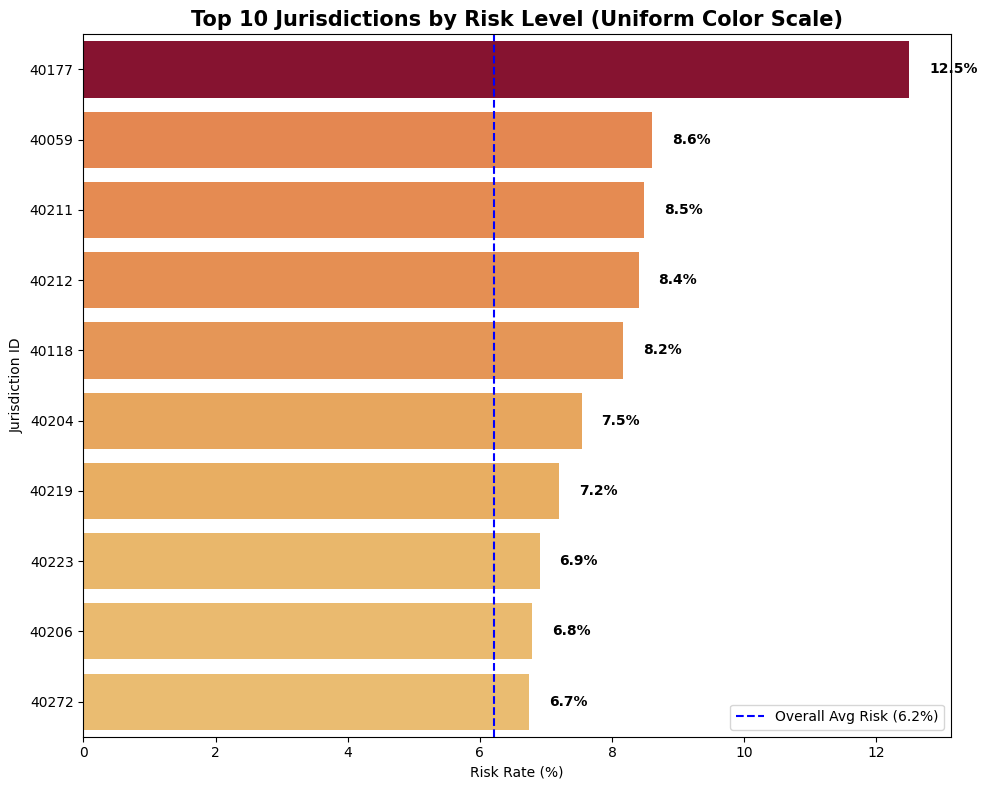

In [25]:
v_min, v_max = 3.7, 13
norm = mcolors.Normalize(vmin=v_min, vmax=v_max)
colormap = plt.get_cmap('YlOrRd')

juris_stats = df_vis.groupby('jurisdiction')['will_die'].agg(['mean', 'count'])
filtered_juris = juris_stats[juris_stats['count'] > 20].sort_values(by='mean', ascending=False).head(10)
filtered_juris_rates = filtered_juris['mean'] * 100

colors = [colormap(norm(value)) for value in filtered_juris_rates.values]

plt.figure(figsize=(10, 8))
sns.barplot(x=filtered_juris_rates.values, y=filtered_juris_rates.index.astype(str), palette=colors, hue=filtered_juris_rates.index.astype(str))

overall_avg = df_vis['will_die'].mean() * 100
plt.axvline(overall_avg, color='blue', linestyle='--', label=f'Overall Avg Risk ({overall_avg:.1f}%)')
plt.title('Top 10 Jurisdictions by Risk Level (Uniform Color Scale)', fontsize=15, fontweight='bold')
plt.xlabel('Risk Rate (%)')
plt.ylabel('Jurisdiction ID')
plt.legend()

for i, v in enumerate(filtered_juris_rates.values):
    plt.text(v + 0.3, i, f'{v:.1f}%', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

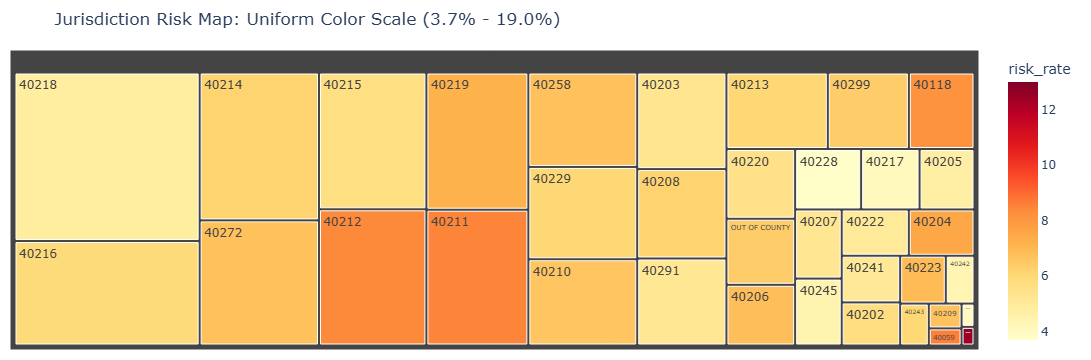

In [26]:
import plotly.express as px

juris_summary = df_vis.groupby('jurisdiction').agg(count=('will_die', 'count'), risk_rate=('will_die', 'mean')).reset_index()
juris_summary['risk_rate'] *= 100
juris_summary = juris_summary[juris_summary['count'] > 20]

fig = px.treemap(juris_summary,
                 path=['jurisdiction'],
                 values='count',
                 color='risk_rate',
                 color_continuous_scale='YlOrRd',
                 range_color=[3.7, 13.0],
                 title='Jurisdiction Risk Map: Uniform Color Scale (3.7% - 19.0%)')

fig.update_layout(margin=dict(t=50, l=10, r=10, b=10))
fig.show()

In [ ]:
import folium

risk_stats = df_vis.groupby('jurisdiction')['will_die'].agg(['mean', 'count']).reset_index()
risk_stats['risk_rate'] = risk_stats['mean'] * 100
risk_stats['jurisdiction'] = risk_stats['jurisdiction'].astype(str)

ky_zip_geojson = 'https://raw.githubusercontent.com/OpenDataDE/State-zip-code-GeoJSON/master/ky_kentucky_zip_codes_geo.min.json'

m = folium.Map(location=[38.20, -85.70], zoom_start=11, tiles='CartoDB positron')

choropleth = folium.Choropleth(
    geo_data=ky_zip_geojson,
    name='Risk Rate by Zip Code',
    data=risk_stats,
    columns=['jurisdiction', 'risk_rate'],
    key_on='feature.properties.ZCTA5CE10',
    fill_color='YlOrRd',
    fill_opacity=0.7,
    line_opacity=0.4,
    legend_name='Risk Rate (%)',
    nan_fill_color='white',
    highlight=True
).add_to(m)

shelter_lat, shelter_lon = 38.2045, -85.6661
folium.Marker(
    [shelter_lat, shelter_lon],
    popup='<b>Louisville Metro Animal Services</b>',
    tooltip='Shelter Location',
    icon=folium.Icon(color='blue', icon='home', prefix='fa')
).add_to(m)

folium.CircleMarker(
    [shelter_lat, shelter_lon],
    radius=15,
    color='blue',
    fill=True,
    fill_opacity=0.1
).add_to(m)

m

The geographical analysis highlights that the location from which the animal comes is an important variable for predicting its fate.

Hotspots: While some areas are characterized by a high volume of activity (as can be seen in TreeMap), the regional map reveals specific hotspots (like West Point) where the mortality rate is higher than average.

Insight: Marking the shelter on the map illustrates the physical proximity to these hotspots. Identifying the "red spots" allows you to refer to the areas in relation to the shelter.

### Distribution of Animals At Risk by sex and sterilized

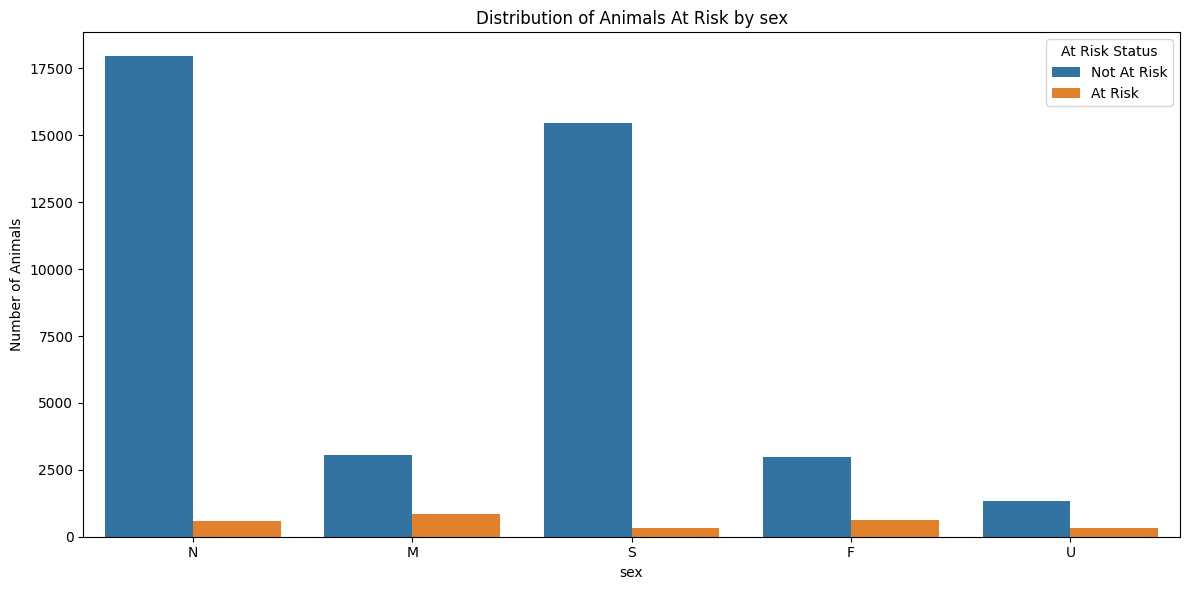

In [28]:
plt.figure(figsize=(12, 6))
sns.countplot(x='sex', hue='will_die', data=df_vis)
plt.title('Distribution of Animals At Risk by sex')
plt.xlabel('sex')
plt.ylabel('Number of Animals')
plt.legend(title='At Risk Status', labels=['Not At Risk', 'At Risk'])
plt.tight_layout()
plt.show()

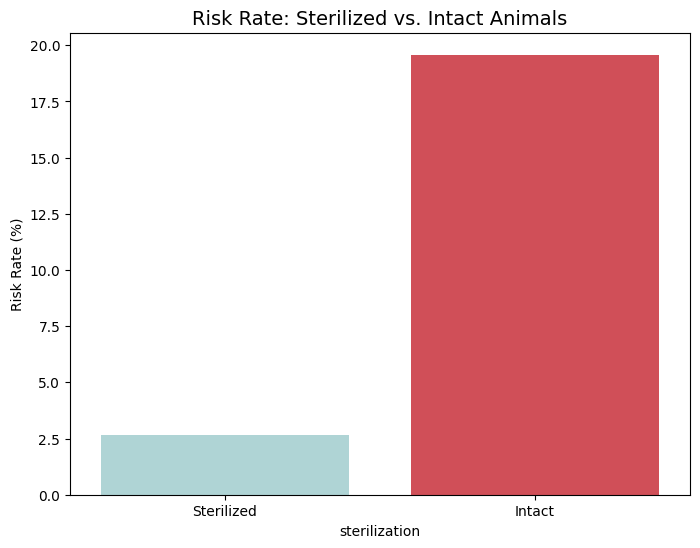

In [29]:
df_vis['sterilization'] = df_vis['sex'].map({'N': 'Sterilized', 'S': 'Sterilized', 'M': 'Intact', 'F': 'Intact'})

plt.figure(figsize=(8, 6))
risk_steril = df_vis.groupby('sterilization')['will_die'].mean().sort_values() * 100
sns.barplot(x=risk_steril.index, y=risk_steril.values, palette=['#a8dadc','#e63946'], hue=risk_steril.index)

plt.title('Risk Rate: Sterilized vs. Intact Animals', fontsize=14)
plt.ylabel('Risk Rate (%)')
plt.show()

The graphs show that spayed or neutered animals are at lower risk.

### Risk Rate by Pet Size

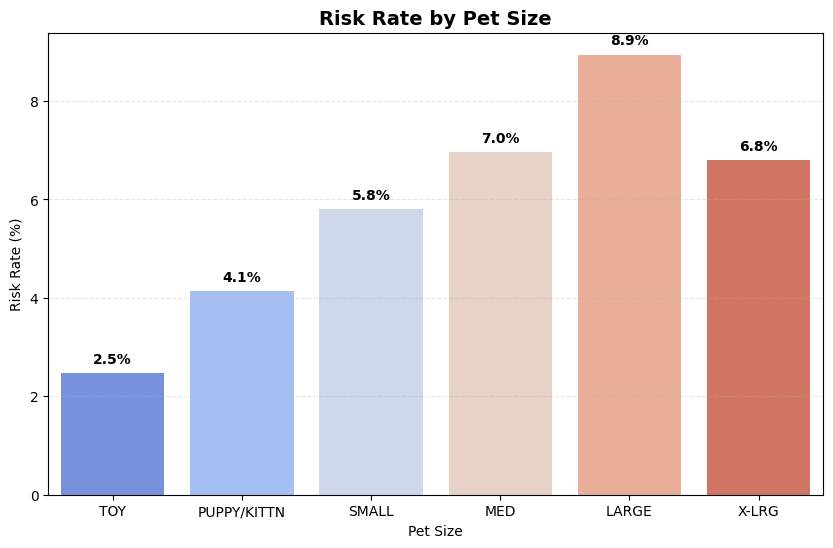

In [30]:
plt.figure(figsize=(10, 6))

size_order = ['TOY', 'PUPPY/KITTN', 'SMALL', 'MED', 'LARGE', 'X-LRG']
risk_by_size = df_vis.groupby('petsize')['will_die'].mean().reindex(size_order) * 100

sns.barplot(x=risk_by_size.index, y=risk_by_size.values, hue=risk_by_size.index, palette='coolwarm')

plt.title('Risk Rate by Pet Size', fontsize=14, fontweight='bold')
plt.ylabel('Risk Rate (%)')
plt.xlabel('Pet Size')

for i, v in enumerate(risk_by_size.values):
    if not np.isnan(v):
        plt.text(i, v + 0.2, f'{v:.1f}%', ha='center', fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

The data shows an interesting trend – as the size of the animal increases, so does its risk rate (especially in the LARGE category).

Key insights:

Large animals: Large dogs often suffer from lower adoption rates due to adopters’ living restrictions (small apartments) or concerns about their behavior, which leads to longer stays in the shelter and increased risk.

Kittens/Puppies: Although they are considered “adoptable,” their risk rate is not zero, which may indicate a higher medical susceptibility to diseases in the shelter.

#  **Supervised Learning – Classification**

## LightBGM

In [31]:
# 1. Define Features and Target
X = df_clean.drop(columns=['will_die'])
y = df_clean['will_die']

# 2. Handle Categorical Variables
categorical_features = X.select_dtypes(include=['object']).columns.tolist()
for col in categorical_features:
    X[col] = X[col].astype('category')

# 3. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4. Calculate Class Weights for Imbalance
neg_count = np.sum(y_train == 0)
pos_count = np.sum(y_train == 1)
calculated_weight = neg_count / pos_count

# 5. Initialize the Model
lgbm = lgb.LGBMClassifier(
    objective='binary',
    boosting_type='gbdt',
    scale_pos_weight=calculated_weight,
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

# 6. Define the Parameter Distributions
param_dist = {
    'n_estimators': randint(50, 100),
    'learning_rate': uniform(0.1, 0.2),
    'num_leaves': randint(10, 20),
    'max_depth': randint(5, 15),
    'min_child_samples': randint(10, 50),
}

# 7. Setup Randomized Search
random_search = RandomizedSearchCV(
    estimator=lgbm,
    param_distributions=param_dist,
    cv=4,
    scoring='average_precision',
    verbose=1,
    n_jobs=-1,
    random_state=42
)

# 8. Execute Search
print("Starting Randomized Search for LightGBM...")
random_search.fit(X_train, y_train)

# 9. Results
print(f"\nBest Parameters: {random_search.best_params_}")
best_model_lgb = random_search.best_estimator_

C:\Users\kfird\AppData\Local\Temp\ipykernel_38492\4089375920.py:6: Pandas4Warning:

For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.



Starting Randomized Search for LightGBM...
Fitting 4 folds for each of 10 candidates, totalling 40 fits

Best Parameters: {'learning_rate': 0.10015575316820287, 'max_depth': 9, 'min_child_samples': 42, 'n_estimators': 61, 'num_leaves': 19}


In [32]:
# 10. Evaluation
# ---------------------------------------------------------
# Get hard predictions for Precision/Recall/F1
y_pred = best_model_lgb.predict(X_test)

# Get probabilities for the positive class (Class 1) for PR AUC
y_proba = best_model_lgb.predict_proba(X_test)[:, 1]

# Calculate metrics
lgbm_precision, lgbm_recall, lgbm_f1, _ = precision_recall_fscore_support(y_test, y_pred)
lgbm_pr_auc = average_precision_score(y_test, y_proba)

print("--- At-Risk (Class 1) Performance ---")
print(f"Precision:         {lgbm_precision[1]:.2f}")
print(f"Recall:            {lgbm_recall[1]:.2f}")
print(f"F1-Score:          {lgbm_f1[1]:.2f}")
print(f"PR AUC:            {lgbm_pr_auc:.2f}")

--- At-Risk (Class 1) Performance ---
Precision:         0.29
Recall:            0.81
F1-Score:          0.42
PR AUC:            0.52


In [33]:
#Prepering Confusion Matrix
y_pred = best_model_lgb.predict(X_test)
y_pred_LGBM = y_pred
y_test_LGBM = y_test
cm_LGBM = confusion_matrix(y_test, y_pred)

## CatBoost

In [34]:
# 1. Define Features and Target
X = df_clean.drop(columns=['will_die'])
X = X.fillna('NaN')
y = df_clean['will_die']

# 2. Identify Categorical Features
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

# 3. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

C:\Users\kfird\AppData\Local\Temp\ipykernel_38492\26568261.py:7: Pandas4Warning:

For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.



In [35]:
# 4. Initialize the Model (בלי cat_features כאן!)
cat_model = CatBoostClassifier(
    loss_function='Logloss',
    auto_class_weights='Balanced',
    random_state=42,
    verbose=False
)

# 5. Define the Hyperparameter Grid
cat_dist = {
    'n_estimators': randint(30, 50),
    'depth': randint(5, 10),
    'learning_rate': uniform(0.01, 0.2),
    'min_data_in_leaf': randint(10, 20)
}

# 6. Use RandomizedSearchCV
rf_random = RandomizedSearchCV(
    estimator=cat_model,
    param_distributions=cat_dist,
    cv=3,
    scoring='average_precision',
    n_jobs=-1,
    random_state=42
)

# 7. Execute Random Search
print("Starting CatBoost Grid Search...")
rf_random.fit(X_train, y_train, cat_features=categorical_features)

# 8. Evaluate
best_model_cat = rf_random.best_estimator_
print(f"\nBest Parameters: {rf_random.best_params_}")

Starting CatBoost Grid Search...


C:\Users\kfird\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning:


2 fits failed out of a total of 30.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
2 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\kfird\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\kfird\AppData\Local\Programs\Python\Python311\Lib\site-packages\catboost\core.py", line 5547, in fit
    self._fit(X, y, cat_features, text_features, embedding_features, None, graph, sample_weight, None, None, None, None, baseline, us


Best Parameters: {'depth': 8, 'learning_rate': 0.1323306320976562, 'min_data_in_leaf': 18, 'n_estimators': 46}


In [36]:
# 9. Evaluation
# ---------------------------------------------------------
# Get hard predictions for Precision/Recall/F1
y_pred = best_model_cat.predict(X_test)

# Get probabilities for the positive class (Class 1) for PR AUC
y_proba = best_model_cat.predict_proba(X_test)[:, 1]

# Calculate metrics
catboost_precision, catboost_recall, catboost_f1, _ = precision_recall_fscore_support(y_test, y_pred)
catboost_pr_auc = average_precision_score(y_test, y_proba)

print("--- At-Risk (Class 1) Performance ---")
print(f"Precision:         {catboost_precision[1]:.2f}")
print(f"Recall:            {catboost_recall[1]:.2f}")
print(f"F1-Score:          {catboost_f1[1]:.2f}")
print(f"PR AUC:            {catboost_pr_auc:.2f}")

--- At-Risk (Class 1) Performance ---
Precision:         0.25
Recall:            0.85
F1-Score:          0.39
PR AUC:            0.51


## Additional Pre-processing (critical for the next models)

In [37]:
df_pre = df_clean.copy()

In [38]:
# Clean Breed & Color directly
df_pre['breed'] = df_pre['breed'].apply(lambda x: str(x).split('/')[0].strip().upper())
df_pre['color'] = df_pre['color'].apply(lambda x: str(x).split('/')[0].strip().upper())

In [39]:
# Cardinality Reduction

def keep_top_n(df_pre, col, n):
    top = df_pre[col].value_counts().nlargest(n).index
    # Replace values not in 'top' with 'Other'
    df_pre[col] = df_pre[col].where(df_pre[col].isin(top), 'Other')

# Apply reduction inplace
keep_top_n(df_pre, 'breed', 20)
keep_top_n(df_pre, 'color', 10)
keep_top_n(df_pre, 'jurisdiction', 10)
keep_top_n(df_pre, 'kennel', 15)
keep_top_n(df_pre, 'insubtype', 10)
keep_top_n(df_pre, 'surreason', 20)

In [40]:
# Define Target and Features
X = df_pre.drop(columns=['will_die'])
y = df_pre['will_die']

# Encoding Categorical Variables
X_encoded = pd.get_dummies(X, drop_first=True)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

## Random Forest

In [41]:
# Initialize Random Forest
rf = RandomForestClassifier(random_state=42, class_weight='balanced')

# Create a pipeline that first applies SMOTE, then fits the model
pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', rf)
])

# ---------------------------------------------------------
# Hyperparameter Tuning
rf_dist = {
    'model__n_estimators': randint(50, 100),      # Range of trees
    'model__max_depth': randint(5, 15),            # Flexible depth
    'model__min_samples_split': randint(2, 20),    # Control splits
    'model__min_samples_leaf': randint(1, 10),     # Prevent Overfitting
    'model__max_features': ['sqrt']        # Feature selection methods
}

# Use RandomizedSearchCV
rf_random = RandomizedSearchCV(
    pipeline,
    param_distributions=rf_dist,
    cv=3,
    scoring='average_precision',
    n_jobs=-1,
    random_state=42
)

rf_random.fit(X_train, y_train)

best_model = rf_random.best_estimator_
print(f"\nBest Parameters found: {rf_random.best_params_}")


Best Parameters found: {'model__max_depth': 14, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 6, 'model__min_samples_split': 13, 'model__n_estimators': 74}


In [42]:
# Evaluation
# ---------------------------------------------------------
# Get hard predictions for Precision/Recall/F1
y_pred = best_model.predict(X_test)

# Get probabilities for the positive class (Class 1) for PR AUC
y_proba = best_model.predict_proba(X_test)[:, 1]

# Calculate metrics
rf_precision, rf_recall, rf_f1, _ = precision_recall_fscore_support(y_test, y_pred)
rf_pr_auc = average_precision_score(y_test, y_proba)

print("--- At-Risk (Class 1) Performance ---")
print(f"Precision:         {rf_precision[1]:.2f}")
print(f"Recall:            {rf_recall[1]:.2f}")
print(f"F1-Score:          {rf_f1[1]:.2f}")
print(f"PR AUC:            {rf_pr_auc:.2f}")

--- At-Risk (Class 1) Performance ---
Precision:         0.28
Recall:            0.75
F1-Score:          0.40
PR AUC:            0.45


## Logistic Regression

In [43]:
# Imbalance Handling & Model Pipeline
# ---------------------------------------------------------

# Initialize Logistic Regression
lr = LogisticRegression(random_state=42, class_weight='balanced')

# Create the pipeline
pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', lr)
])

# ---------------------------------------------------------
# Hyperparameter Tuning (Grid Search)
# ---------------------------------------------------------
param_grid = {
    'model__C': [0.01, 0.1, 1],
    'model__penalty': ['l2'],
    'model__solver': ['lbfgs', 'liblinear']
}

print("\nStarting Grid Search for Logistic Regression...")
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring='average_precision',
    cv=2,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
print(f"\nBest Parameters found: {grid_search.best_params_}")


Starting Grid Search for Logistic Regression...
Fitting 2 folds for each of 6 candidates, totalling 12 fits


C:\Users\kfird\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning:

'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.




Best Parameters found: {'model__C': 0.01, 'model__penalty': 'l2', 'model__solver': 'liblinear'}


In [44]:
# Evaluation
# ---------------------------------------------------------
# Get hard predictions for Precision/Recall/F1
y_pred = best_model.predict(X_test)

# Get probabilities for the positive class (Class 1) for PR AUC
y_proba = best_model.predict_proba(X_test)[:, 1]

# Calculate metrics
lr_precision, lr_recall, lr_f1, _ = precision_recall_fscore_support(y_test, y_pred)
lr_pr_auc = average_precision_score(y_test, y_proba)

print("--- At-Risk (Class 1) Performance ---")
print(f"Precision:         {lr_precision[1]:.2f}")
print(f"Recall:            {lr_recall[1]:.2f}")
print(f"F1-Score:          {lr_f1[1]:.2f}")
print(f"PR AUC:            {lr_pr_auc:.2f}")

--- At-Risk (Class 1) Performance ---
Precision:         0.26
Recall:            0.62
F1-Score:          0.37
PR AUC:            0.35


## MLP

In [45]:
# Setup the Pipeline with SMOTE and MLP
mlp = MLPClassifier(
    random_state=42,
    max_iter=50,
    early_stopping=True,
    batch_size=512
)

pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', mlp)
])

# Define Search Space
param_dist = {
    'model__hidden_layer_sizes': [(50,), (20,30)],
    'model__activation': ['relu'],
    'model__alpha': loguniform(1e-4, 1e-1),
    'model__learning_rate_init': loguniform(1e-3, 1e-2)
}

print("Starting Randomized Search for MLP with Encoded Data...")

# Run Randomized Search
random_search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_dist,
    n_iter=5,
    scoring='average_precision',
    cv=2,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

# Fit on the encoded data
random_search.fit(X_train, y_train)

best_model = random_search.best_estimator_
print(f"\nBest Parameters found: {random_search.best_params_}")

Starting Randomized Search for MLP with Encoded Data...
Fitting 2 folds for each of 5 candidates, totalling 10 fits

Best Parameters found: {'model__activation': 'relu', 'model__alpha': 0.0013292918943162175, 'model__hidden_layer_sizes': (50,), 'model__learning_rate_init': 0.0015255793090045732}


C:\Users\kfird\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.



In [46]:
# Evaluation
# ---------------------------------------------------------
# Get hard predictions for Precision/Recall/F1
y_pred = best_model.predict(X_test)

# Get probabilities for the positive class (Class 1) for PR AUC
y_proba = best_model.predict_proba(X_test)[:, 1]

# Calculate metrics
mlp_precision, mlp_recall, mlp_f1, _ = precision_recall_fscore_support(y_test, y_pred)
mlp_pr_auc = average_precision_score(y_test, y_proba)

print("--- At-Risk (Class 1) Performance ---")
print(f"Precision:         {mlp_precision[1]:.2f}")
print(f"Recall:            {mlp_recall[1]:.2f}")
print(f"F1-Score:          {mlp_f1[1]:.2f}")
print(f"PR AUC:            {mlp_pr_auc:.2f}")

--- At-Risk (Class 1) Performance ---
Precision:         0.40
Recall:            0.51
F1-Score:          0.45
PR AUC:            0.43


# **Best Model & Feature Importance**

In [47]:
metrics_data = {
    'Model': ['LightGBM', 'CatBoost', 'Random Forest', 'Logistic Regression', 'MLP'],
    'PR AUC': [lgbm_pr_auc, catboost_pr_auc, rf_pr_auc, lr_pr_auc, mlp_pr_auc],
    'Recall': [lgbm_recall[1], catboost_recall[1], rf_recall[1], lr_recall[1], mlp_recall[1]],
    'Precision': [lgbm_precision[1], catboost_precision[1], rf_precision[1], lr_precision[1], mlp_precision[1]],
    'F1-Score': [lgbm_f1[1], catboost_f1[1], rf_f1[1], lr_f1[1], mlp_f1[1]]
}

performance_df = pd.DataFrame(metrics_data)
performance_df = performance_df.sort_values(by='PR AUC', ascending=False).reset_index(drop=True)
display(performance_df)

,Model,PR AUC,Recall,Precision,F1-Score
0,LightGBM,0.522190,0.805556,0.286939,0.423152
1,CatBoost,0.513241,0.850000,0.253311,0.390306
2,Random Forest,0.448025,0.751852,0.275441,0.403178
3,MLP,0.428623,0.511111,0.397695,0.447326
4,Logistic Regression,0.348306,0.622222,0.262500,0.369231


After looking at the perfomance of all the models, the best model is *LightGBM*, thanks to its PR-AUC score.

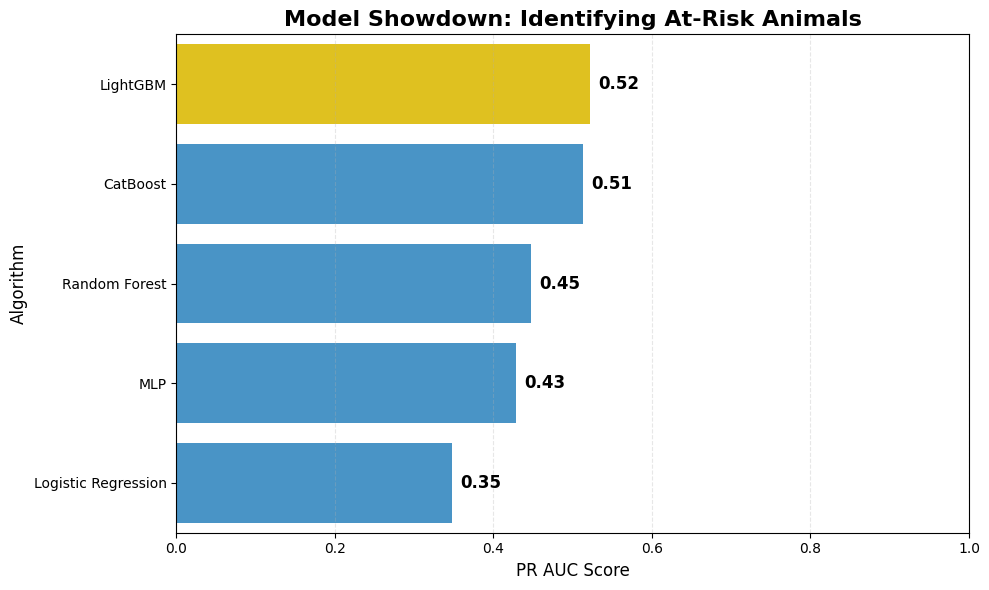

In [48]:
results_df = pd.DataFrame(metrics_data).sort_values(by='PR AUC', ascending=False)

plt.figure(figsize=(10, 6))

colors = ['#FFD700' if x == 'LightGBM' else '#3498db' for x in results_df['Model']]

sns.barplot(
    x='PR AUC',
    y='Model',
    data=results_df,
    hue='Model',
    palette=colors,
    legend=False
)

plt.title('Model Showdown: Identifying At-Risk Animals', fontsize=16, fontweight='bold')
plt.xlabel('PR AUC Score', fontsize=12)
plt.ylabel('Algorithm', fontsize=12)
plt.xlim(0, 1.0)

for i, v in enumerate(results_df['PR AUC']):
    plt.text(v + 0.01, i, f'{v:.2f}', va='center', fontweight='bold', fontsize=12)

plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

Note: We chose to optimize PR AUC rather than Recall to ensure a balance between identifying at-risk cases and minimizing false alarms. While optimizing for Recall alone often forces the model to cast too wide a net, PR AUC ensures the model is fundamentally better at distinguishing the minority class effectively across all decision thresholds.

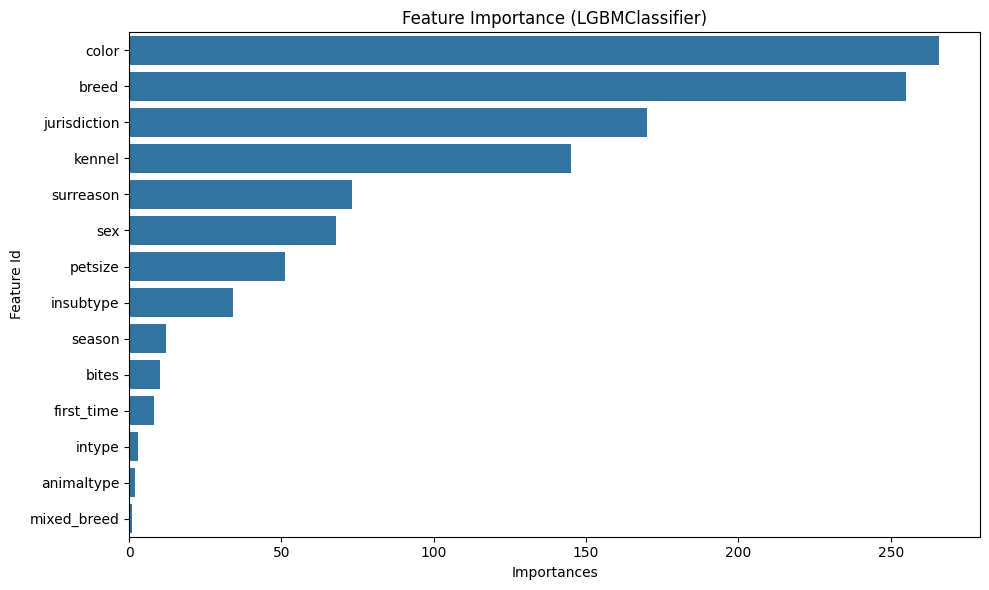

In [49]:
# 1. Create the DataFrame manually
importance_df = pd.DataFrame({
    'Feature Id': best_model_lgb.feature_name_,
    'Importances': best_model_lgb.feature_importances_
}).sort_values(by='Importances', ascending=False)

# 2. Plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Importances', y='Feature Id', data=importance_df)
plt.title('Feature Importance (LGBMClassifier)')
plt.tight_layout()
plt.show()

Confusion Matrix: Optimized LightGBM

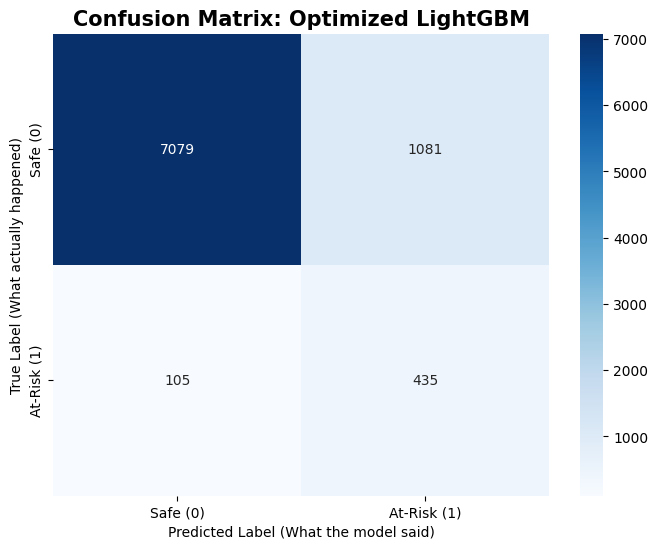

In [50]:
# Plot of Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_LGBM, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Safe (0)', 'At-Risk (1)'],
            yticklabels=['Safe (0)', 'At-Risk (1)'])

plt.title('Confusion Matrix: Optimized LightGBM', fontsize=15, fontweight='bold')
plt.xlabel('Predicted Label (What the model said)')
plt.ylabel('True Label (What actually happened)')

plt.show()

#  **Unsupervised Analysis**

##### Note: In few of the following plots we were using the help of AI

## K-Modes

In [51]:
# 1. Data Preparation and Encoding for Silhouette
X_encoded = X.apply(lambda col: pd.factorize(col)[0])
X_sample = X_encoded.sample(20000, random_state=42) #Just for The Silhouette Score

costs = []
silhouette_scores = []
K = range(2, 6)

print("Starting Clustering Analysis...")

for k in K:
    # 2. Run K-Modes Clustering
    km = KModes(n_clusters=k, init='Huang', n_init=5, random_state=42)
    labels = km.fit_predict(X_sample)

    # 3. Store Cost (Inertia equivalent)
    costs.append(km.cost_)

    # 4. Calculate Silhouette Score using Hamming Distance
    score = silhouette_score(X_sample, labels, metric='hamming')
    silhouette_scores.append(score)
    print(f"k={k} completed: Cost={km.cost_:.0f}, Silhouette={score:.4f}")

Starting Clustering Analysis...
k=2 completed: Cost=118253, Silhouette=0.2719
k=3 completed: Cost=106718, Silhouette=0.1720
k=4 completed: Cost=102011, Silhouette=0.1304
k=5 completed: Cost=97342, Silhouette=0.1518


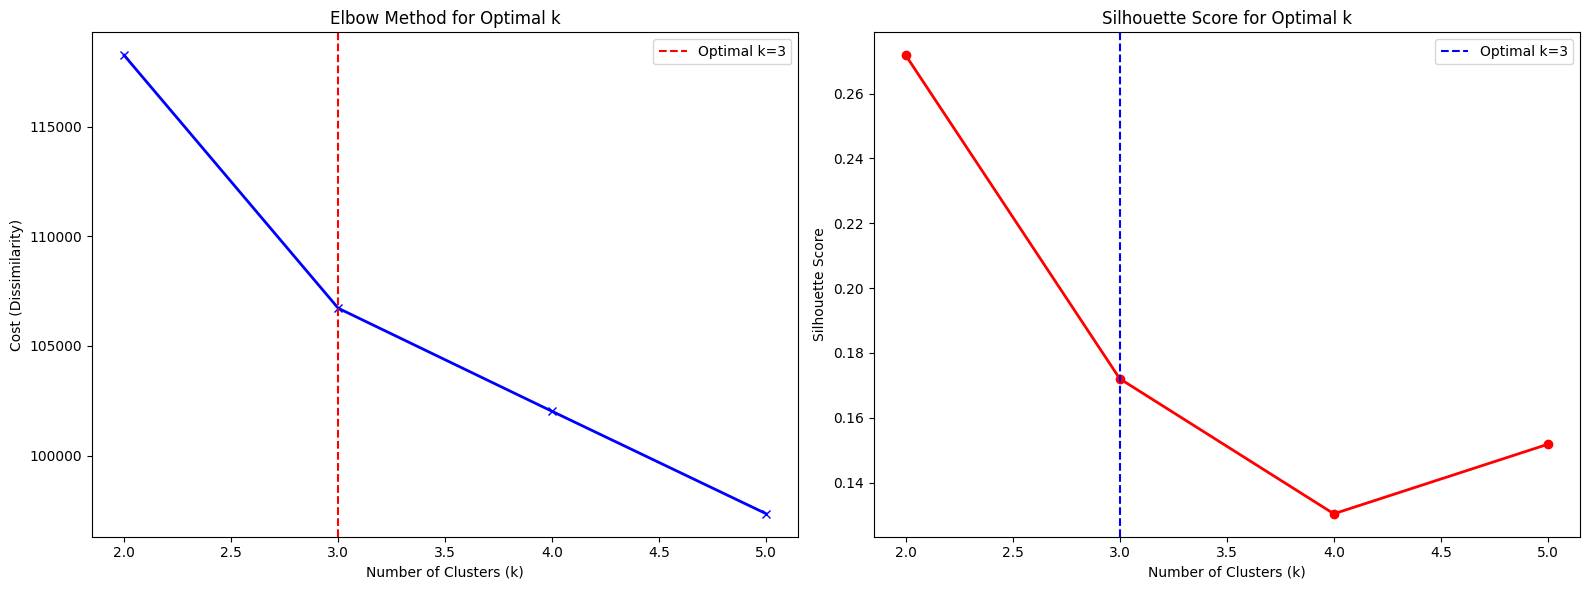

In [52]:
# 5. Visualization: Side-by-Side Comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot Elbow Method (Cost)
ax1.plot(K, costs, 'bx-', linewidth=2)
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Cost (Dissimilarity)')
ax1.set_title('Elbow Method for Optimal k')
ax1.axvline(x=3, color='r', linestyle='--', label='Optimal k=3')
ax1.legend()

# Plot Silhouette Analysis
ax2.plot(K, silhouette_scores, 'ro-', linewidth=2)
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score for Optimal k')
ax2.axvline(x=3, color='b', linestyle='--', label='Optimal k=3')
ax2.legend()

plt.tight_layout()
plt.show()

**Optimal k Selection (Elbow Method)**

**The Elbow plot illustrates a significant reduction in cost (dissimilarity) until
k=3
, after which we observe diminishing returns. This 'elbow' point indicates that 3 clusters provide the optimal balance between model complexity and the ability to distinguish meaningful risk archetypes, capturing the primary variance in the dataset without over-fitting.**

In [53]:
# Initialize K-Modes
km = KModes(n_clusters=3, n_init=10)

# Fit the clusters
clusters = km.fit_predict(X)

# Add the cluster labels back to your original dataframe
df_pre['risk_profile'] = clusters

In [54]:
# Calculate mortality rate per cluster
risk_analysis = df_pre.groupby('risk_profile')['will_die'].mean().reset_index()
risk_analysis.columns = ['Cluster', 'Mortality_Rate']

# Sort to find the "High Risk" profiles
risk_analysis = risk_analysis.sort_values(by='Mortality_Rate', ascending=False)
print(risk_analysis)

   Cluster  Mortality_Rate
2        2        0.086133
0        0        0.063218
1        1        0.034971


### K-modes Visual

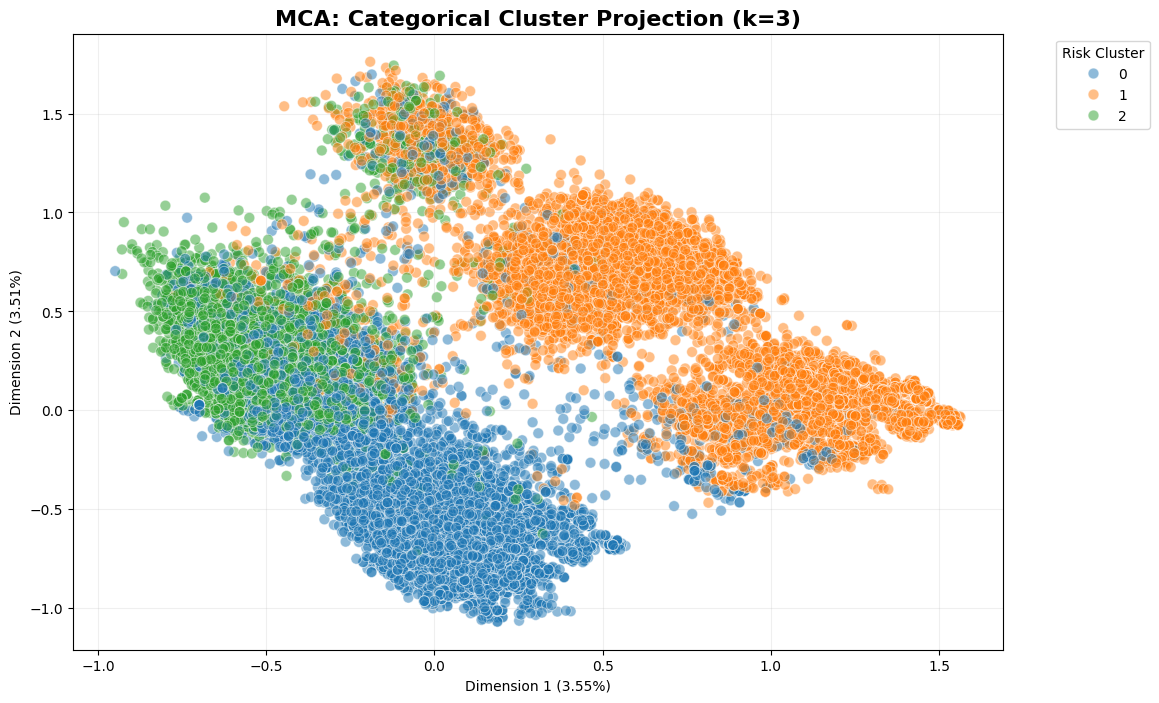

In [55]:
# 1. Define the model - reduce to 2 components (Dimensions)
mca = prince.MCA(
    n_components=2,
    n_iter=3,
    copy=True,
    check_input=True,
    engine='sklearn',
    random_state=42
)

# 2. Run on the categorical data (X)
mca = mca.fit(X)

# 3. Get the coordinates for plotting
mca_coords = mca.row_coordinates(X)
mca_coords.columns = ['Dimension 1', 'Dimension 2']
mca_coords['Cluster'] = df_pre['risk_profile'].astype(str)

# 4. Visualization
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='Dimension 1',
    y='Dimension 2',
    hue='Cluster',
    data=mca_coords,
    palette='tab10',
    alpha=0.5,
    s=60
)

plt.title('MCA: Categorical Cluster Projection (k=3)', fontsize=16, fontweight='bold')
plt.xlabel(f'Dimension 1 ({mca.eigenvalues_summary.iloc[0, 1]})')
plt.ylabel(f'Dimension 2 ({mca.eigenvalues_summary.iloc[1, 1]})')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Risk Cluster')
plt.grid(True, alpha=0.2)
plt.show()

## Hierarchical Clustering

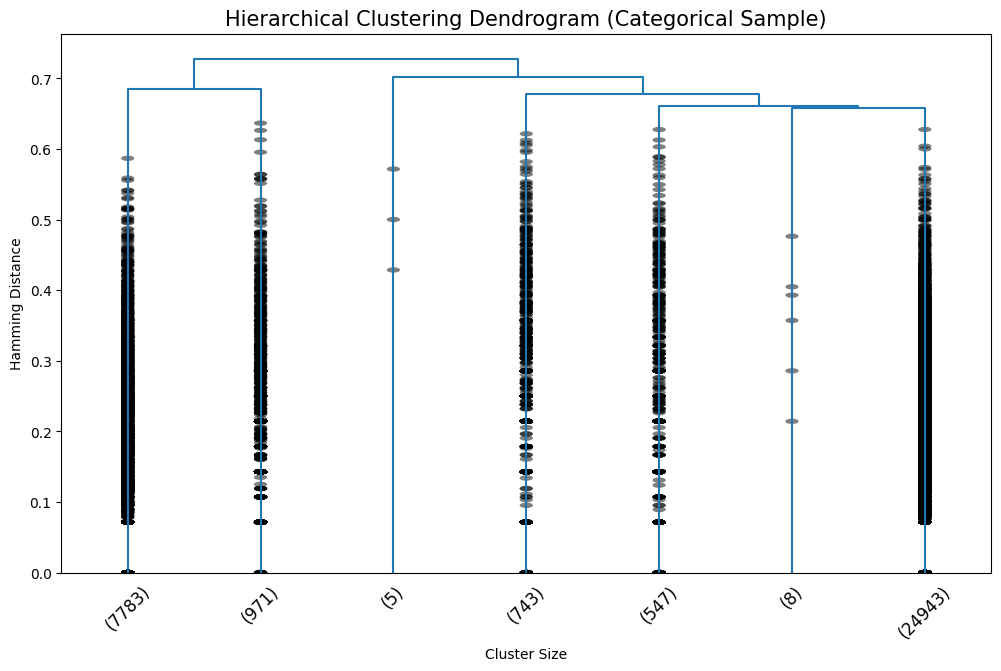

In [56]:
# 1. Convert words to ordinal numbers (Label Encoding)
# The factorize command converts each word to a unique number
X_numeric = X.apply(lambda col: pd.factorize(col)[0])

# 2. Now we sample from the numerical data
X_sample = X_numeric.sample(35000, random_state=42)

# 3. Run the Linkage
Z = linkage(X_sample, method='average', metric='hamming')

# 4. Plot the dendrogram
plt.figure(figsize=(12, 7))
dendrogram(Z, truncate_mode='lastp', p=7, leaf_rotation=45, show_contracted=True)
plt.title('Hierarchical Clustering Dendrogram (Categorical Sample)', fontsize=15)
plt.xlabel('Cluster Size')
plt.ylabel('Hamming Distance')
plt.show()

## K-modes VS Hierarchical Clustering

In [57]:
# 1. Prepare the data (sample of 30000 rows for performance)
X_numeric = X.apply(lambda col: pd.factorize(col)[0])
X_sample = X_numeric.sample(30000, random_state=42)

def calculate_cluster_metrics(data, labels):
    # Calculate cluster centroids (the Mode for each cluster)
    centroids = []
    wss = 0 # Cohesion

    unique_labels = np.unique(labels)
    for label in unique_labels:
        cluster_points = data[labels == label]
        if len(cluster_points) > 0:
            # The Mode is the categorical "center"
            mode_val = cluster_points.mode().iloc[0].values
            centroids.append(mode_val)
            # WSS: Sum of Hamming distances of points from the center
            wss += np.sum(cluster_points.values != mode_val)

    # BSS: Distance between cluster centers (Separation)
    centroids = np.array(centroids)
    if len(centroids) > 1:
        # Average distance between each pair of centers
        bss = np.mean(pdist(centroids, metric='hamming'))
    else:
        bss = 0

    # Silhouette: The combined metric
    sil = silhouette_score(data, labels, metric='hamming')

    return wss, bss, sil

# --- Calculation for K-Modes (Method 1) ---
labels_kmodes = df_pre.loc[X_sample.index, 'risk_profile']
wss_km, bss_km, sil_km = calculate_cluster_metrics(X_sample, labels_kmodes)

# --- Calculation for Hierarchical (Method 2) ---
hc = AgglomerativeClustering(n_clusters=10, metric='hamming', linkage='average')
labels_hc = hc.fit_predict(X_sample)
wss_hc, bss_hc, sil_hc = calculate_cluster_metrics(X_sample, labels_hc)

# Display results in a table for comparison
results = pd.DataFrame({
    'Metric': ['Cohesion (WSS - Lower is better)', 'Separation (BSS - Higher is better)', 'Silhouette Score'],
    'K-Modes': [wss_km, f"{bss_km:.3f}", f"{sil_km:.3f}"],
    'Hierarchical': [wss_hc, f"{bss_hc:.3f}", f"{sil_hc:.3f}"]
})

display(results)

,Metric,K-Modes,Hierarchical
0,Cohesion (WSS - Lower is better),164638,172742
1,Separation (BSS - Higher is better),0.595,0.654
2,Silhouette Score,0.159,0.153


###**Analysis of Clustering Results: K-Modes vs. Hierarchical**

The comparative analysis, conducted on a representative sample of 30,000 records (~75% of the dataset), highlights a fundamental trade-off between the two architectures:

* Internal Cohesion (WSS): K-Modes demonstrated a clear advantage in internal consistency, achieving a significantly lower Within-cluster Sum of Squares (WSS) compared to the Hierarchical model. This indicates that K-Modes is more effective at "tightening" animals into homogeneous groups, which is essential for defining stable and reliable risk archetypes for shelter management.

* Cluster Separation (BSS): The Hierarchical model achieved higher scores in Between-cluster Separation (BSS). While this suggests that the Hierarchical method creates more distinct boundaries between clusters, these clusters exhibit higher internal variance (lower cohesion), making them less actionable for specific clinical or behavioral interventions.

####**Conclusion & Model Selection**

The higher Silhouette score of the K-Modes make him selected as the final model. The decision is driven by its superior Cohesion, which ensures that each "Risk Profile" represents a highly similar group of animals. Furthermore, K-Modes offers better scalability for the full dataset and aligns natively with the categorical nature of the shelter’s data attributes.

## High Risk Profile by K-modes

In [58]:
# Get the modes of each cluster
cluster_centroids = pd.DataFrame(km.cluster_centroids_, columns=X.columns)
cluster_centroids['Mortality_Rate'] = risk_analysis['Mortality_Rate'].values

# Display the characteristics of the highest-risk cluster
print("High Risk Profile Characteristics:")
print(cluster_centroids.iloc[0])

High Risk Profile Characteristics:
kennel                      C
jurisdiction            Other
intype                  STRAY
insubtype                 OTC
surreason               STRAY
animaltype                CAT
sex                         N
bites                       N
petsize                   MED
color                   BLACK
breed             DOMESTIC SH
first_time                  1
mixed_breed                 0
season                 Summer
Mortality_Rate       0.086133
Name: 0, dtype: object


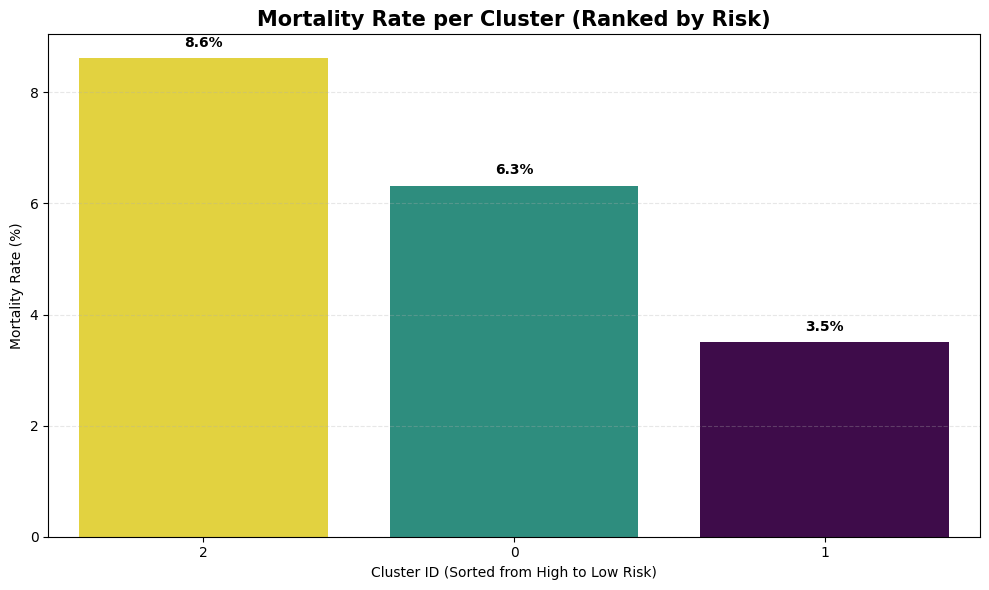

In [59]:
risk_analysis['Mortality_Rate_Pct'] = risk_analysis['Mortality_Rate'] * 100
risk_analysis_sorted = risk_analysis.sort_values(by='Mortality_Rate_Pct', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    x='Cluster',
    y='Mortality_Rate_Pct',
    data=risk_analysis_sorted,
    order=risk_analysis_sorted['Cluster'],
    palette='viridis',
    hue=risk_analysis_sorted['Mortality_Rate_Pct'],
    legend=False
)

plt.title('Mortality Rate per Cluster (Ranked by Risk)', fontsize=15, fontweight='bold')
plt.ylabel('Mortality Rate (%)')
plt.xlabel('Cluster ID (Sorted from High to Low Risk)')

for i, v in enumerate(risk_analysis_sorted['Mortality_Rate_Pct']):
    plt.text(i, v + 0.2, f'{v:.1f}%', ha='center', fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()